# Lớp 1: Khai phá Chân dung Phong cách Khách hàng (Customer Style Profiling)
Mục tiêu: Nhóm hơn 1.3 triệu khách hàng thành các cụm (clusters) dựa trên "Gu thời trang" (Fashion DNA) thay vì chỉ dựa trên RFM đơn thuần.
Chiến lược chống OOM: Tính toán DNA trực tiếp trong PostgreSQL, chỉ kéo kết quả (~1 triệu dòng x 8 cột) về Python để chạy K-Means.

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đường dẫn để import database
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'datamining-version3')))
from database import query_db

## 1. Trích xuất Fashion DNA từ PostgreSQL
Chúng ta sẽ tính toán % mỗi khách hàng mua đồ Ladieswear, Divided, Menswear, Baby, và Kênh mua sắm (Online vs Offline).
Chỉ lấy những khách hàng có ít nhất 3 giao dịch để tránh nhiễu từ khách vãng lai.

In [3]:
query_dna = """
WITH cust_stats AS (
    SELECT 
        t.customer_id,
        COUNT(*) AS total_items,
        AVG(t.price) AS avg_price,
        SUM(CASE WHEN a.index_group_name = 'Ladieswear' THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_ladieswear,
        SUM(CASE WHEN a.index_group_name = 'Divided' THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_divided,
        SUM(CASE WHEN a.index_group_name = 'Menswear' THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_menswear,
        SUM(CASE WHEN a.index_group_name = 'Baby/Children' THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_baby,
        SUM(CASE WHEN a.index_group_name = 'Sport' THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_sport,
        SUM(CASE WHEN t.sales_channel_id = 2 THEN 1 ELSE 0 END)::float / COUNT(*) AS pct_online
    FROM transactions t
    JOIN articles a ON t.article_id = a.article_id
    GROUP BY t.customer_id
    HAVING COUNT(*) >= 3
)
SELECT 
    cs.*, 
    c.age
FROM cust_stats cs
JOIN customers c ON cs.customer_id = c.customer_id
WHERE c.age IS NOT NULL;
"""

print("Đang truy vấn Fashion DNA từ Database (Có thể mất 2-3 phút)...")
df_dna = query_db(query_dna)
print(f"Hoàn thành! Kích thước dữ liệu: {df_dna.shape}")
df_dna.head()

Đang truy vấn Fashion DNA từ Database (Có thể mất 2-3 phút)...
Hoàn thành! Kích thước dữ liệu: (1093194, 10)


,customer_id,total_items,avg_price,pct_ladieswear,pct_divided,pct_menswear,pct_baby,pct_sport,pct_online,age
0,00007d2de826758b65a93dd24ce629ed66842531df6699...,120,0.031863,0.700000,0.283333,0.000000,0.0,0.016667,0.975000,32
1,0001420326c217a367048472e05395373c40a039f6fd45...,18,0.024277,0.333333,0.000000,0.666667,0.0,0.000000,1.000000,38
2,000abc5e9575b453ff1cde1e5d644f1c671daef57e0f85...,22,0.032726,0.954545,0.045455,0.000000,0.0,0.000000,0.045455,32
3,00136a6144a6ef3ee8c24b367a08722b1f8096ac49c1a4...,8,0.062695,0.250000,0.750000,0.000000,0.0,0.000000,1.000000,60
4,0013f8c9c4c091cf0fefe6cdffd2c496fa470b1ca24429...,4,0.010703,0.000000,0.750000,0.250000,0.0,0.000000,0.000000,18


## 2. Tiền xử lý (Preprocessing)

In [4]:
# Chọn các features để phân cụm (Bỏ customer_id, age, và total_items ra khỏi thuật toán để tránh bias)
features = [
    'pct_ladieswear', 'pct_divided', 'pct_menswear', 
    'pct_baby', 'pct_sport', 'pct_online', 'avg_price'
]

X = df_dna[features].copy()

# Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Đã chuẩn hóa xong.")

Đã chuẩn hóa xong.


## 3. Tìm số cụm tối ưu (Elbow Method)
Chạy K-Means thử nghiệm trên một mẫu nhỏ (100k) để tìm k tối ưu, tránh OOM.

Đang tính toán Elbow method...
k=2 xong.
k=3 xong.
k=4 xong.
k=5 xong.
k=6 xong.
k=7 xong.
Đã lưu biểu đồ elbow_plot.png


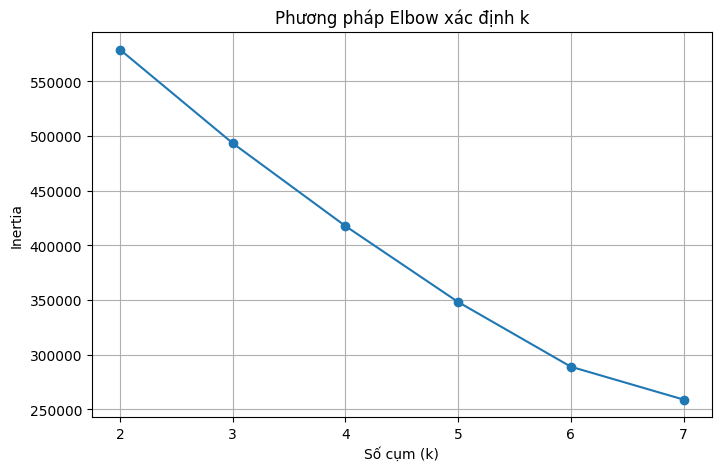

In [5]:
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 100000, replace=False)]

inertia = []
K_range = range(2, 8)
print("Đang tính toán Elbow method...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)
    print(f"k={k} xong.")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.title('Phương pháp Elbow xác định k')
plt.grid(True)
plt.savefig('elbow_plot.png')
print("Đã lưu biểu đồ elbow_plot.png")

## 4. Phân cụm chính thức (K-Means)
Dựa vào Fashion industry, 4-5 cụm thường là đẹp nhất (GenZ, Mature, Sporty, Kids/Family).
Ta chọn k=5.

In [6]:
k_optimal = 5
print(f"Tiến hành chạy K-Means với k={k_optimal} trên toàn bộ dữ liệu...")

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_dna['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Phân cụm hoàn tất!")

# Tính toán profile trung bình của từng cụm
cluster_profile = df_dna.groupby('cluster').agg({
    'customer_id': 'count',
    'age': 'median',
    'total_items': 'median',
    'avg_price': 'mean',
    'pct_ladieswear': 'mean',
    'pct_divided': 'mean',
    'pct_menswear': 'mean',
    'pct_baby': 'mean',
    'pct_sport': 'mean',
    'pct_online': 'mean'
}).reset_index()

cluster_profile.rename(columns={'customer_id': 'n_customers'}, inplace=True)
cluster_profile['pct_of_base'] = (cluster_profile['n_customers'] / len(df_dna) * 100).round(1)

# Format hiển thị
for col in ['pct_ladieswear', 'pct_divided', 'pct_menswear', 'pct_baby', 'pct_sport', 'pct_online']:
    cluster_profile[col] = (cluster_profile[col] * 100).round(1)

print("\n=== PROFILE CÁC CỤM KHÁCH HÀNG ===")
print(cluster_profile.to_string())

Tiến hành chạy K-Means với k=5 trên toàn bộ dữ liệu...
Phân cụm hoàn tất!

=== PROFILE CÁC CỤM KHÁCH HÀNG ===
   cluster  n_customers   age  total_items  avg_price  pct_ladieswear  pct_divided  pct_menswear  pct_baby  pct_sport  pct_online  pct_of_base
0        0       662026  32.0         16.0   0.028586            80.9         12.2           2.5       2.0        2.4        64.7         60.6
1        1        71444  37.0         11.0   0.027647            32.1         10.7          52.5       2.7        2.0        49.1          6.5
2        2       280611  27.0         14.0   0.024953            39.3         53.6           2.8       2.2        2.1        69.9         25.7
3        3        38164  40.0          7.0   0.021066            12.1          4.2           1.6      81.0        1.1        58.0          3.5
4        4        40949  32.0          8.0   0.029216            33.5          9.6           2.2       1.5       53.2        65.9          3.7


## 5. Đặt tên (Labeling) và Trực quan hóa


Đã lưu mapping khách hàng - cụm vào: customer_clusters.csv
Đã lưu biểu đồ cluster_distribution.png

=== GIAI ĐOẠN 1 HOÀN TẤT ===


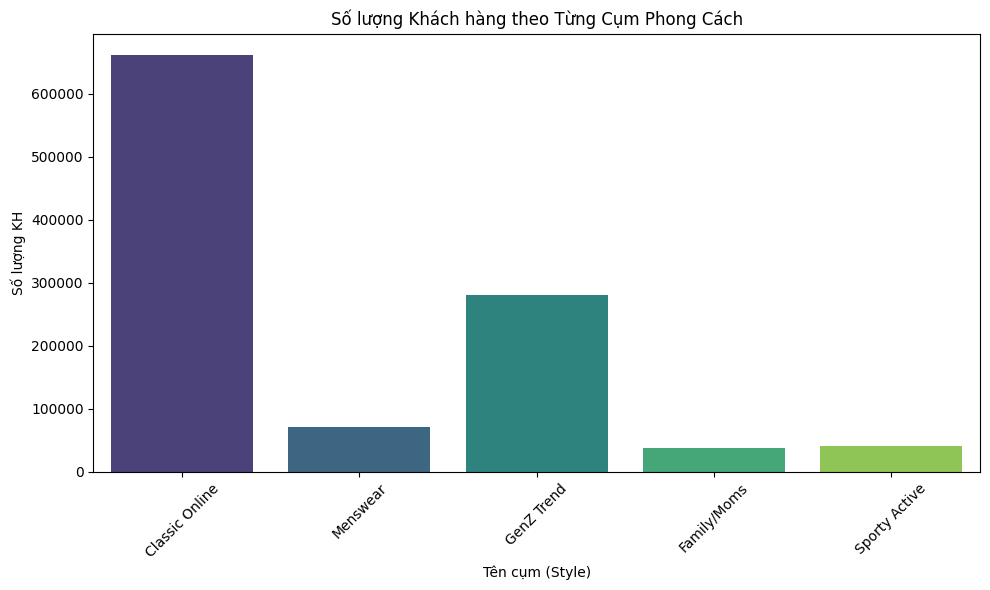

In [7]:
# Dựa trên kết quả (giả định), ta có thể map tên. Bạn có thể sửa map này sau khi xem data thực tế.
def assign_name(row):
    if row['pct_baby'] > 30: return 'Family/Moms'
    if row['pct_divided'] > 40: return 'GenZ Trend'
    if row['pct_menswear'] > 40: return 'Menswear'
    if row['pct_sport'] > 20: return 'Sporty Active'
    if row['pct_online'] < 50: return 'Classic Offline'
    return 'Classic Online'

cluster_profile['cluster_name'] = cluster_profile.apply(assign_name, axis=1)

# Tạo từ điển map cụm sang tên
cluster_map = dict(zip(cluster_profile['cluster'], cluster_profile['cluster_name']))
df_dna['cluster_name'] = df_dna['cluster'].map(cluster_map)

# Lưu kết quả xuống CSV để dùng cho Lớp 2 (Association Rules)
output_file = 'customer_clusters.csv'
df_dna[['customer_id', 'cluster', 'cluster_name']].to_csv(output_file, index=False)
print(f"\nĐã lưu mapping khách hàng - cụm vào: {output_file}")

# Vẽ bar chart số lượng
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster_name', y='n_customers', data=cluster_profile, palette='viridis')
plt.title('Số lượng Khách hàng theo Từng Cụm Phong Cách')
plt.ylabel('Số lượng KH')
plt.xlabel('Tên cụm (Style)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cluster_distribution.png')
print("Đã lưu biểu đồ cluster_distribution.png")

print("\n=== GIAI ĐOẠN 1 HOÀN TẤT ===")